<a href="https://colab.research.google.com/github/mperumal-usd/capstone_team_3/blob/main/notebooks/COLAB_MERT_Finetune_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MERT Fine-Tuning with LoRA: Composer Similarity (v5)

Fine-tunes `m-a-p/MERT-v1-95M` using LoRA adapters on all attention projections.
No projection head — the 768-dim L2-normalized MERT output is used directly with TripletMarginLoss.

## Sections
- **Section 0** — Setup (install deps, mount Drive, config)
- **Section 1** — Triplet CSV generation (always regenerated)
- **Section 2** — Train/val split (skips if Drive files exist)
- **Section 3** — LoRA training (intra-epoch checkpointing every N steps)
- **Section 4** — Evaluation

**Resume after disconnect:** Run all cells top-to-bottom. Each section checks Drive for its checkpoint and skips if already done. Training resumes from the last saved step.

In [1]:
# ── Section 0: Setup ──────────────────────────────────────────────────────────
!pip install -q transformers peft accelerate librosa numpy pandas scikit-learn tqdm

from google.colab import drive
drive.mount('/content/drive')

import os, json, random, re
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import librosa
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
DRIVE_BASE   = "/content/drive/MyDrive/AAI-590 Capstone/checkpoints5"
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
MODEL_NAME       = "m-a-p/MERT-v1-95M"
MODEL_CACHE_DIR  = "/content/drive/MyDrive/AAI-590 Capstone/checkpoints5/model_cache"
SR           = 24000
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]
MARGIN       = 0.3
CNN_FILTERS  = 256           # filters per scale in CNN temporal encoder
CNN_KERNELS  = (3, 5, 7)     # multi-scale kernel sizes (frames)
EMBED_DIM    = 128           # final embedding dimension
BATCH_SIZE   = 8        # each triplet = 3 WAV forward passes through MERT
LR           = 5e-5
EPOCHS       = 10
SAVE_STEPS   = 1        # save full checkpoint to Drive after every optimizer step
GRAD_CLIP    = 1.0      # gradient clipping max norm (0 = disabled)
SEED         = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Create Drive subdirectories
for sub in ["splits", "checkpoints/lora_best", "checkpoints/lora_last", "results", "model_cache"]:
    os.makedirs(os.path.join(DRIVE_BASE, sub), exist_ok=True)
print("Drive folders ready.")

Mounted at /content/drive
Device: cuda
Drive folders ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
TRIPLET_CSV = os.path.join(DRIVE_BASE, "triplet_df.csv")

## Section 1 — Triplet CSV Generation
Regenerates (anchor, positive, negative) DataFrame from ChunkSamples and saves to Drive.
Always re-runs (~30 seconds). Anchor = first chunk of each song; positives = remaining chunks;
negative = chunks from a randomly chosen different composer.

In [ ]:
# ── Section 1: Triplet CSV ────────────────────────────────────────────────────
TRIPLET_CSV = os.path.join(DRIVE_BASE, "triplet_df.csv")

def numeric_sort(f):
    match = re.search(r'_chunk_(\d+)\.wav$', f)
    return int(match.group(1)) if match else -1

data = []
used_negatives = set()

for composer in os.listdir(CHUNK_PATH):
    composer_path = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(composer_path):
        continue
    for song in os.listdir(composer_path):
        song_path = os.path.join(composer_path, song)
        if not os.path.isdir(song_path):
            continue
        chunks = sorted(
            [f for f in os.listdir(song_path) if f.endswith(".wav")],
            key=numeric_sort
        )
        if len(chunks) < 2:
            continue
        anchor    = chunks[0]
        positives = chunks[1:]
        other_composers = [
            c for c in os.listdir(CHUNK_PATH)
            if c != composer and os.path.isdir(os.path.join(CHUNK_PATH, c))
        ]
        if not other_composers:
            continue
        chosen_composer      = random.choice(other_composers)
        chosen_composer_path = os.path.join(CHUNK_PATH, chosen_composer)
        negative_pool = []
        for other_song in sorted(os.listdir(chosen_composer_path)):
            other_song_path = os.path.join(chosen_composer_path, other_song)
            if not os.path.isdir(other_song_path):
                continue
            for f in sorted(os.listdir(other_song_path), key=numeric_sort):
                if f.endswith(".wav") and f not in used_negatives:
                    negative_pool.append(f)
        min_len = min(len(positives), len(negative_pool))
        for i in range(min_len):
            data.append({
                "anchor":   anchor,
                "positive": positives[i],
                "negative": negative_pool[i],
                "composer": composer,
                "song":     song,
            })
            used_negatives.add(negative_pool[i])

df = pd.DataFrame(data)
df.to_csv(TRIPLET_CSV, index=False)
print(f"Triplet CSV saved → {TRIPLET_CSV}")
print(f"Total triplets: {len(df)}")
print(df.head())

In [3]:
df = pd.read_csv(TRIPLET_CSV)
print(f"Triplet CSV saved → {TRIPLET_CSV}")
print(f"Total triplets: {len(df)}")
print(df.head())

Triplet CSV saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/triplet_df.csv
Total triplets: 23183
                 anchor              positive             negative composer  \
0  bach_847_chunk_1.wav  bach_847_chunk_2.wav  islamei_chunk_1.wav     bach   
1  bach_847_chunk_1.wav  bach_847_chunk_3.wav  islamei_chunk_2.wav     bach   
2  bach_847_chunk_1.wav  bach_847_chunk_4.wav  islamei_chunk_3.wav     bach   
3  bach_847_chunk_1.wav  bach_847_chunk_5.wav  islamei_chunk_4.wav     bach   
4  bach_847_chunk_1.wav  bach_847_chunk_6.wav  islamei_chunk_5.wav     bach   

       song  
0  bach_847  
1  bach_847  
2  bach_847  
3  bach_847  
4  bach_847  


## Section 2 — Train/Val Split
80/20 stratified split on composer. Skips if Drive files already exist.

In [5]:
# ── Section 2: Train/val split ────────────────────────────────────────────────
TRAIN_IDX_PATH = os.path.join(DRIVE_BASE, "splits", "train_idx.npy")
VAL_IDX_PATH   = os.path.join(DRIVE_BASE, "splits",   "val_idx.npy")

if os.path.exists(TRAIN_IDX_PATH) and os.path.exists(VAL_IDX_PATH):
    train_idx = np.load(TRAIN_IDX_PATH)
    val_idx   = np.load(VAL_IDX_PATH)
    print(f"Loaded split from Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")
else:
    all_idx = np.arange(len(df))
    train_idx, val_idx = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=SEED,
        stratify=df["composer"].values
    )
    np.save(TRAIN_IDX_PATH, train_idx)
    np.save(VAL_IDX_PATH,   val_idx)
    print(f"Split saved to Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
print(f"train_df: {len(train_df)} rows  val_df: {len(val_df)} rows")

Loaded split from Drive. Train: 18546  Val: 4637
train_df: 18546 rows  val_df: 4637 rows


## Section 3 — LoRA Training

### Architecture
```
MERT-v1-95M
  + LoRA adapters on q_proj, k_proj, v_proj, o_proj (all transformer layers)
  → mean-pool last_hidden_state → 768-dim
  → L2-normalize → 768-dim unit-sphere embedding
Loss: TripletMarginLoss(margin=0.3)
```

### Resume behaviour
Training state is saved every `SAVE_STEPS` optimizer steps to Drive (`training_state.json`).
On resume, the LoRA adapter and optimizer are reloaded and the loop skips already-completed batches.

In [7]:
# ── Section 3A: Dataset + Model setup ────────────────────────────────────────

# Build filename → full path lookup
file_lookup = {}
for composer in os.listdir(CHUNK_PATH):
    cp = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(cp):
        continue
    for song in os.listdir(cp):
        sp = os.path.join(cp, song)
        if not os.path.isdir(sp):
            continue
        for f in os.listdir(sp):
            if f.endswith(".wav"):
                file_lookup[f] = os.path.join(sp, f)
print(f"File lookup built: {len(file_lookup)} files")


class TripletWAVDataset(Dataset):
    """Loads WAV triplets on-the-fly from filenames."""
    def __init__(self, dataframe, file_lookup, processor, sr=24000):
        self.df          = dataframe.reset_index(drop=True)
        self.file_lookup = file_lookup
        self.processor   = processor
        self.sr          = sr

    def __len__(self):
        return len(self.df)

    def _load(self, fname):
        path  = self.file_lookup.get(fname)
        audio, _ = librosa.load(path, sr=self.sr)
        inputs   = self.processor(audio, sampling_rate=self.sr, return_tensors="pt")
        # squeeze batch dim added by processor
        return {k: v.squeeze(0) for k, v in inputs.items()}

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return (
            self._load(row["anchor"]),
            self._load(row["positive"]),
            self._load(row["negative"]),
        )


def collate_triplets(batch):
    """Stack variable-length inputs by padding to the longest in the batch."""
    anchors, positives, negatives = zip(*batch)

    def stack(items):
        # items is a list of dicts; pad input_values to same length
        max_len = max(x["input_values"].shape[-1] for x in items)
        padded  = []
        for x in items:
            iv = x["input_values"]  # (seq_len,)
            pad_len = max_len - iv.shape[-1]
            padded.append(F.pad(iv, (0, pad_len)))
        return {"input_values": torch.stack(padded)}

    return stack(anchors), stack(positives), stack(negatives)


# ── Load processor + base model (Drive cache → HuggingFace fallback) ────────
if os.path.isdir(MODEL_CACHE_DIR) and os.listdir(MODEL_CACHE_DIR):
    print(f"Loading MERT from Drive cache: {MODEL_CACHE_DIR}")
    processor  = AutoProcessor.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
    base_model = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
else:
    print("Drive cache not found. Downloading from HuggingFace...")
    processor  = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
    base_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
    processor.save_pretrained(MODEL_CACHE_DIR)
    base_model.save_pretrained(MODEL_CACHE_DIR)
    print(f"Model cached to Drive: {MODEL_CACHE_DIR}")


# ── CNN Temporal Projection Head ────────────────────────────────────────────
import torch.nn as nn
class CNNProjectionHead(nn.Module):
    """
    Replaces mean-pooling with learned multi-scale temporal aggregation.

    Input : last_hidden_state  (batch, seq_len, 768)
    Output: L2-normalised embedding  (batch, EMBED_DIM)

    Three parallel Conv1d streams with different kernel sizes capture
    local (3-frame), mid (5-frame) and broader (7-frame) temporal patterns.
    Their global-average-pooled outputs are concatenated, then projected
    to EMBED_DIM via a two-layer MLP with LayerNorm + GELU.
    """
    def __init__(self, input_dim=768, num_filters=256,
                 kernel_sizes=(3, 5, 7), embed_dim=128, dropout=0.1):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(input_dim, num_filters, k, padding=k // 2),
                nn.BatchNorm1d(num_filters),
                nn.GELU(),
            )
            for k in kernel_sizes
        ])
        fused = num_filters * len(kernel_sizes)
        self.proj = nn.Sequential(
            nn.Linear(fused, fused // 2),
            nn.LayerNorm(fused // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fused // 2, embed_dim),
        )

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        # hidden_states: (batch, seq_len, 768)
        x = hidden_states.transpose(1, 2)           # → (batch, 768, seq_len)
        pooled = [conv(x).mean(dim=2) for conv in self.convs]
        x = torch.cat(pooled, dim=1)                # (batch, num_filters * n_kernels)
        return F.normalize(self.proj(x), p=2, dim=1)  # (batch, embed_dim)


# Apply LoRA
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGETS,
    lora_dropout=LORA_DROPOUT,
    bias="none",
)
model = get_peft_model(base_model, lora_config)
model.to(DEVICE)
model.print_trainable_parameters()

# Instantiate CNN projection head
cnn_head = CNNProjectionHead(
    input_dim    = 768,
    num_filters  = CNN_FILTERS,
    kernel_sizes = CNN_KERNELS,
    embed_dim    = EMBED_DIM,
    dropout      = 0.1,
).to(DEVICE)
cnn_params = sum(p.numel() for p in cnn_head.parameters())
print(f"CNN projection head: {cnn_params:,} params  (filters={CNN_FILTERS}, kernels={CNN_KERNELS}, embed={EMBED_DIM})")

# DataLoaders
train_dataset = TripletWAVDataset(train_df, file_lookup, processor, SR)
val_dataset   = TripletWAVDataset(val_df,   file_lookup, processor, SR)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)

criterion = torch.nn.TripletMarginLoss(margin=MARGIN, p=2)
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(cnn_head.parameters()), lr=LR
)
total_steps = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")
print(f"Total training steps: {total_steps}")

# ── Mixed-precision (AMP) setup ──────────────────────────────────────────────
use_amp = DEVICE.type == "cuda"
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)
print(f"Mixed precision (AMP): {use_amp}")


File lookup built: 43663 files
Loading MERT from Drive cache: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/model_cache


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

trainable params: 442,368 || all params: 94,814,080 || trainable%: 0.4666
CNN projection head: 3,296,768 params  (filters=256, kernels=(3, 5, 7), embed=128)
Train batches: 2319  Val batches: 580
Total training steps: 23190
Mixed precision (AMP): True


/tmp/ipykernel_6588/18749039.py:167: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)


In [8]:
# ── Section 3B: Training loop ─────────────────────────────────────────────────
LORA_BEST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_best")
LORA_LAST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_last")
CNN_BEST_PATH  = os.path.join(DRIVE_BASE, "checkpoints", "cnn_head_best.pt")
CNN_LAST_PATH  = os.path.join(DRIVE_BASE, "checkpoints", "cnn_head_last.pt")
OPT_STATE_PATH = os.path.join(DRIVE_BASE, "checkpoints", "optimizer_state.pt")
TRAIN_STATE    = os.path.join(DRIVE_BASE, "checkpoints", "training_state.json")
LOG_PATH       = os.path.join(DRIVE_BASE, "training_log.csv")


def get_embedding(model, batch_inputs):
    """Forward through LoRA-MERT → CNN projection head → L2-normed EMBED_DIM embedding."""
    inputs = {k: v.to(DEVICE) for k, v in batch_inputs.items()}
    outputs = model(**inputs)
    hidden = outputs.last_hidden_state      # (batch, seq_len, 768)
    return cnn_head(hidden)                 # (batch, EMBED_DIM) L2-normed


In [9]:


# ── Resume ────────────────────────────────────────────────────────────────────
start_epoch   = 0
resume_step   = 0       # steps already completed inside start_epoch
global_step   = 0
best_val_loss = float("inf")
training_log  = []

if os.path.exists(TRAIN_STATE):
    with open(TRAIN_STATE) as f:
        state = json.load(f)
    start_epoch   = state["epoch"]
    resume_step   = state["step"]       # batches done in start_epoch
    global_step   = state["global_step"]
    best_val_loss = state["best_val_loss"]
    # Load a fresh base model so PeftModel.from_pretrained has no stale
    # peft_config attached — avoids the "Already found peft_config" warning
    # and guarantees the new optimizer points at the correct parameters.
    opt_ckpt = torch.load(OPT_STATE_PATH, map_location=DEVICE)
    fresh_base = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
    model = PeftModel.from_pretrained(fresh_base, LORA_LAST_DIR)
    model.to(DEVICE)
    if os.path.exists(CNN_LAST_PATH):
        cnn_head.load_state_dict(torch.load(CNN_LAST_PATH, map_location=DEVICE))
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(cnn_head.parameters()), lr=LR
    )
    optimizer.load_state_dict(opt_ckpt["optimizer"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    scheduler.load_state_dict(opt_ckpt["scheduler"])
    if "scaler" in opt_ckpt:
        scaler.load_state_dict(opt_ckpt["scaler"])
    print(f"Resumed: epoch={start_epoch} step={resume_step} global_step={global_step}")
else:
    print("No checkpoint found. Training from scratch.")

if os.path.exists(LOG_PATH):
    training_log = pd.read_csv(LOG_PATH).to_dict(orient="records")


def save_checkpoint(is_best=False, end_of_epoch=False):
    """Save LoRA adapter + optimizer/scheduler/scaler state to Drive.
    end_of_epoch=True advances epoch/step so resume skips no batches.
    """
    model.save_pretrained(LORA_LAST_DIR)
    torch.save(cnn_head.state_dict(), CNN_LAST_PATH)
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler":    scaler.state_dict(),
    }, OPT_STATE_PATH)
    with open(TRAIN_STATE, "w") as f:
        json.dump({
            "epoch":         epoch + 1 if end_of_epoch else epoch,
            "step":          0         if end_of_epoch else batch_idx + 1,
            "global_step":   global_step,
            "best_val_loss": best_val_loss,
        }, f)
    if is_best:
        model.save_pretrained(LORA_BEST_DIR)
        torch.save(cnn_head.state_dict(), CNN_BEST_PATH)


# ── Training ──────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    model.train()
    cnn_head.train()
    train_loss_total = 0.0
    train_batches    = 0

    for batch_idx, (a_in, p_in, n_in) in enumerate(
        tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    ):
        # Skip already-completed batches on resume
        if epoch == start_epoch and batch_idx < resume_step:
            scheduler.step()
            global_step += 1
            continue

        with torch.cuda.amp.autocast(enabled=use_amp):
            a_emb = get_embedding(model, a_in)
            p_emb = get_embedding(model, p_in)
            n_emb = get_embedding(model, n_in)
            loss  = criterion(a_emb, p_emb, n_emb)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        if GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(cnn_head.parameters()), GRAD_CLIP
            )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss_total += loss.item()
        train_batches    += 1
        global_step      += 1

        # Intra-epoch checkpoint
        if global_step % SAVE_STEPS == 0:
            save_checkpoint(is_best=False)

    avg_train_loss = train_loss_total / max(train_batches, 1)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    cnn_head.eval()
    val_loss_total = 0.0
    val_pos_sim    = 0.0
    val_neg_sim    = 0.0

    with torch.no_grad():
        for a_in, p_in, n_in in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]"):
            with torch.cuda.amp.autocast(enabled=use_amp):
                a_emb = get_embedding(model, a_in)
                p_emb = get_embedding(model, p_in)
                n_emb = get_embedding(model, n_in)
                loss  = criterion(a_emb, p_emb, n_emb)
            val_loss_total += loss.item()
            val_pos_sim += F.cosine_similarity(a_emb, p_emb).mean().item()
            val_neg_sim += F.cosine_similarity(a_emb, n_emb).mean().item()

    avg_val_loss = val_loss_total / len(val_loader)
    avg_pos_sim  = val_pos_sim   / len(val_loader)
    avg_neg_sim  = val_neg_sim   / len(val_loader)

    # ── Log ───────────────────────────────────────────────────────────────────
    is_best = avg_val_loss < best_val_loss
    if is_best:
        best_val_loss = avg_val_loss

    row = {
        "epoch":       epoch + 1,
        "global_step": global_step,
        "train_loss":  round(avg_train_loss, 6),
        "val_loss":    round(avg_val_loss,   6),
        "val_pos_sim": round(avg_pos_sim,    4),
        "val_neg_sim": round(avg_neg_sim,    4),
        "val_gap":     round(avg_pos_sim - avg_neg_sim, 4),
        "lr":          optimizer.param_groups[0]["lr"],
        "best":        is_best,
    }
    training_log.append(row)
    pd.DataFrame(training_log).to_csv(LOG_PATH, index=False)

    # Save end-of-epoch checkpoint (and best if improved)
    save_checkpoint(is_best=is_best, end_of_epoch=True)
    resume_step = 0   # next epoch starts from batch 0

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f} "
        f"pos_sim={avg_pos_sim:.4f} neg_sim={avg_neg_sim:.4f} "
        f"gap={avg_pos_sim - avg_neg_sim:.4f}"
        + ("  ✓ best" if is_best else "")
    )

print(f"\nTraining complete. Best val_loss={best_val_loss:.4f}")
print(f"Best LoRA adapter → {LORA_BEST_DIR}")

No checkpoint found. Training from scratch.


Epoch 1/10 [train]:   0%|          | 0/2319 [00:00<?, ?it/s]/tmp/ipykernel_6588/1951960872.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/10 [val]:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_6588/1951960872.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/10 [val]: 100%|██████████| 580/580 [20:01<00:00,  2.07s/it]


Epoch 01 | train_loss=0.0993 val_loss=0.0950 pos_sim=0.5630 neg_sim=0.0784 gap=0.4846  ✓ best


Epoch 2/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.20it/s]


Epoch 02 | train_loss=0.0560 val_loss=0.0628 pos_sim=0.5149 neg_sim=-0.0997 gap=0.6145  ✓ best


...

Epoch 08 | train_loss=0.0125 val_loss=0.0404 pos_sim=0.5475 neg_sim=-0.0514 gap=0.5989


Epoch 9/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.21it/s]


Epoch 09 | train_loss=0.0110 val_loss=0.0302 pos_sim=0.5196 neg_sim=-0.1301 gap=0.6497  ✓ best


Epoch 10/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.03it/s]

Epoch 10 | train_loss=0.0102 val_loss=0.0320 pos_sim=0.5208 neg_sim=-0.1277 gap=0.6486

Training complete. Best val_loss=0.0302
Best LoRA adapter → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/lora_best


## Section 4 — Evaluation
Loads the best LoRA adapter and computes cosine similarity distributions on the val set.
Saves results and a 2-panel histogram to Drive.

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Best LoRA adapter loaded from /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/lora_best
Best CNN head loaded  from /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/cnn_head_best.pt


Evaluating:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_6588/896868102.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating: 100%|██████████| 580/580 [00:37<00:00, 15.58it/s]


finetune_pos_mean  0.5196
finetune_neg_mean -0.1300
finetune_gap       0.6496
finetune_pos_std   0.2693
finetune_neg_std   0.2963


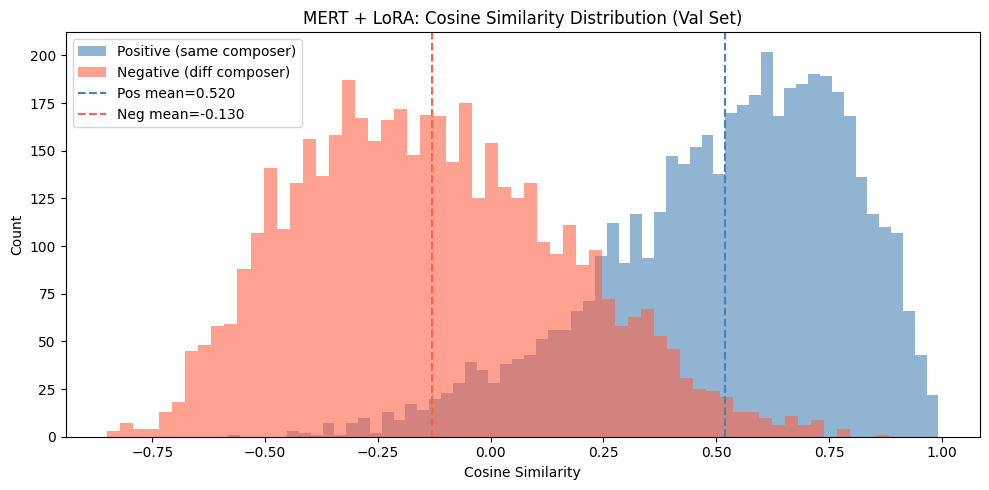

Plot saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/score_plot.png
Eval results saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/eval_results.csv


In [10]:
# ── Section 4: Evaluation ─────────────────────────────────────────────────────
EVAL_CSV  = os.path.join(DRIVE_BASE, "results", "eval_results.csv")
PLOT_PATH = os.path.join(DRIVE_BASE, "results", "score_plot.png")

# Load best LoRA adapter + CNN projection head
eval_base  = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
eval_model = PeftModel.from_pretrained(eval_base, LORA_BEST_DIR)
eval_model.to(DEVICE)
eval_model.eval()
cnn_head.load_state_dict(torch.load(CNN_BEST_PATH, map_location=DEVICE))
cnn_head.eval()
print(f"Best LoRA adapter loaded from {LORA_BEST_DIR}")
print(f"Best CNN head loaded  from {CNN_BEST_PATH}")

# ── Compute fine-tuned cosine similarities on val set ─────────────────────────
ft_pos_sims, ft_neg_sims = [], []

with torch.no_grad():
    for a_in, p_in, n_in in tqdm(val_loader, desc="Evaluating"):
        with torch.cuda.amp.autocast(enabled=use_amp):
            a_emb = get_embedding(eval_model, a_in)
            p_emb = get_embedding(eval_model, p_in)
            n_emb = get_embedding(eval_model, n_in)
        ft_pos_sims.append(F.cosine_similarity(a_emb, p_emb).cpu().numpy())
        ft_neg_sims.append(F.cosine_similarity(a_emb, n_emb).cpu().numpy())

ft_pos_sim = np.concatenate(ft_pos_sims)
ft_neg_sim = np.concatenate(ft_neg_sims)

# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    "finetune_pos_mean": round(float(ft_pos_sim.mean()), 4),
    "finetune_neg_mean": round(float(ft_neg_sim.mean()), 4),
    "finetune_gap":      round(float(ft_pos_sim.mean() - ft_neg_sim.mean()), 4),
    "finetune_pos_std":  round(float(ft_pos_sim.std()),  4),
    "finetune_neg_std":  round(float(ft_neg_sim.std()),  4),
}
results_df = pd.DataFrame([results])
results_df.to_csv(EVAL_CSV, index=False)
print(results_df.T.to_string(header=False))

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ft_pos_sim, bins=60, alpha=0.6, label="Positive (same composer)", color="steelblue")
ax.hist(ft_neg_sim, bins=60, alpha=0.6, label="Negative (diff composer)", color="tomato")
ax.axvline(ft_pos_sim.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Pos mean={ft_pos_sim.mean():.3f}")
ax.axvline(ft_neg_sim.mean(), color="tomato",    linestyle="--", linewidth=1.5,
           label=f"Neg mean={ft_neg_sim.mean():.3f}")
ax.set_title("MERT + LoRA: Cosine Similarity Distribution (Val Set)")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f"Plot saved → {PLOT_PATH}")
print(f"Eval results saved → {EVAL_CSV}")

## Section 5 — Extract All Embeddings
Extracts embeddings for all chunks in the dataset using the best fine-tuned model and saves them to a DataFrame.

In [ ]:
# ── Section 5: Extract All Embeddings ─────────────────────────────────────────

all_files = list(file_lookup.keys())

class AllChunksDataset(Dataset):
    """Dataset for extracting embeddings from all chunks."""
    def __init__(self, file_list, file_lookup, processor, sr=24000):
        self.file_list   = file_list
        self.file_lookup = file_lookup
        self.processor   = processor
        self.sr          = sr

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        path  = self.file_lookup[fname]
        audio, _ = librosa.load(path, sr=self.sr)
        inputs   = self.processor(audio, sampling_rate=self.sr, return_tensors="pt")
        return fname, {k: v.squeeze(0) for k, v in inputs.items()}

def collate_all_chunks(batch):
    fnames, items = zip(*batch)
    max_len = max(x["input_values"].shape[-1] for x in items)
    padded  = []
    for x in items:
        iv = x["input_values"]
        pad_len = max_len - iv.shape[-1]
        padded.append(F.pad(iv, (0, pad_len)))
    return fnames, {"input_values": torch.stack(padded)}

all_dataset = AllChunksDataset(all_files, file_lookup, processor, SR)
all_loader  = DataLoader(
    all_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)

results_data = []
eval_model.eval()
cnn_head.eval()

with torch.no_grad():
    for fnames, batch_inputs in tqdm(all_loader, desc="Extracting all embeddings"):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_embedding(eval_model, batch_inputs)
        embs_np = embs.cpu().numpy()

        for fname, emb in zip(fnames, embs_np):
            chunk_match = re.search(r'_chunk_(\d+)\.wav$', fname)
            chunk_num = int(chunk_match.group(1)) if chunk_match else -1
            results_data.append({
                "filename": fname,
                "chunk": chunk_num,
                "embeddings": emb
            })

all_embeddings_df = pd.DataFrame(results_data)

# Save to pickle to preserve numpy arrays naturally
EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "all_embeddings.pkl")
all_embeddings_df.to_pickle(EMBEDDINGS_PATH)

print(f"\nSaved {len(all_embeddings_df)} embeddings to {EMBEDDINGS_PATH}")
display(all_embeddings_df.head())

Extracting all embeddings:  12%|█▏        | 672/5458 [02:58<2:08:08,  1.61s/it]